<a href="https://colab.research.google.com/github/rafiq9090/Learning-AI/blob/main/Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ['preg', 'gluc', 'bp', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
df = pd.read_csv(url, names=names)
# checking data
print(df.head())
x = df.drop('class', axis=1)
y = df['class']
print("---count---")
print(df.shape)

   preg  gluc  bp  skin  test  mass   pedi  age  class
0     6   148  72    35     0  33.6  0.627   50      1
1     1    85  66    29     0  26.6  0.351   31      0
2     8   183  64     0     0  23.3  0.672   32      1
3     1    89  66    23    94  28.1  0.167   21      0
4     0   137  40    35   168  43.1  2.288   33      1
---count---
(768, 9)


Trining and divide test set

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

Training Model

In [17]:
model = LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

Checking Accuracy

In [19]:
predictions = model.predict(x_test)
print(f"\n model accuracy:{accuracy_score(y_test,predictions)*100:.2f}%")


 model accuracy:75.32%


save this model

In [20]:
import joblib
joblib.dump(model,'diabets_model.pkl')
joblib.dump(scaler,'scaler.pkl')

print("Successfully save scaler model")

Successfully save scaler model


new people data add in model

In [22]:
loaded_model = joblib.load('diabets_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

# new patient data
feature_names = ['preg', 'gluc', 'bp', 'skin', 'test', 'mass', 'pedi', 'age']
# [Pregnancies, Glucose, BP, Skin, Insulin, BMI, Pedigree, Age]
new_patient = pd.DataFrame([[2, 120, 70, 20, 80, 25.5, 0.5, 30]],columns=feature_names)

# scaler the data
new_patient_scaled = loaded_scaler.transform(new_patient)
# predictions
prediction = loaded_model.predict(new_patient_scaled)
if predictions[0] == 1:
    print("The person is diabetic")
else:
    print("The person is not diabetic")


The person is not diabetic


Random Forest Classifier

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

# accuracy check

rf_predictions = rf_model.predict(x_test)
print(f"\n model accuracy:{accuracy_score(y_test,rf_predictions)*100:.2f}%")



 model accuracy:72.08%


Feature Importance

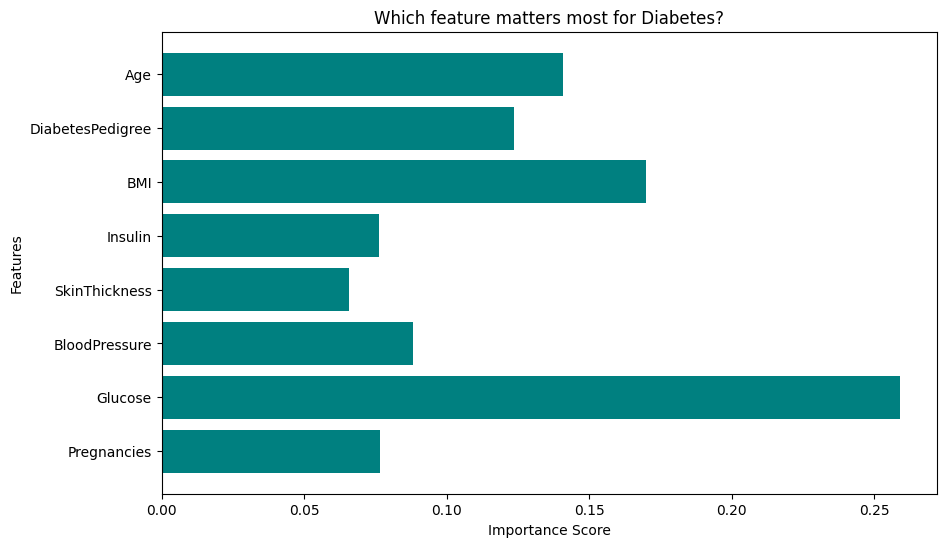

In [25]:
import matplotlib.pyplot as plt

features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigree', 'Age']
importances = rf_model.feature_importances_

#create graph
plt.figure(figsize=(10, 6))
plt.barh(features, importances, color='teal')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Which feature matters most for Diabetes?')
plt.show()